In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)

df = pd.read_csv("titanic (1).csv")
print(f"Loaded: {df.shape[0]} passenger records, {df.shape[1]} columns")
df.head()

Loaded: 1000 passenger records, 7 columns


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,2,female,17.8,0,0,23.94
1,0,3,male,18.5,1,0,29.07
2,0,3,male,26.6,1,0,17.63
3,0,3,male,34.7,0,2,13.72
4,1,1,male,42.0,0,0,128.90


Part A — The Classification Setup  
TASK 01  
Encode, split, and standardize

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Encode binary categoricals: convert Sex to binary (female = 1, male = 0)
df['Sex'] = (df['Sex'] == 'female').astype(int)

# Separate features X and binary target y = Survived.
x = df.drop(columns=['Survived'])
y = df['Survived'].values

# Split into training (80%) and test (20%) sets with stratify=y and fixed random_state=42.
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize features using StandardScaler fit strictly on training data.
scaler = StandardScaler().fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)


print('Training Feature:', x_train_scaled.shape)
print('Test Feature:', x_test_scaled.shape)
print('Training Targets:', y_train.shape)
print('Test Targets:', y_test.shape)

Training Feature: (800, 6)
Test Feature: (200, 6)
Training Targets: (800,)
Test Targets: (200,)


Part B — Build and Prove (The Core Deliverable)  
TASK 02  
The Sigmoid function and Log-Loss

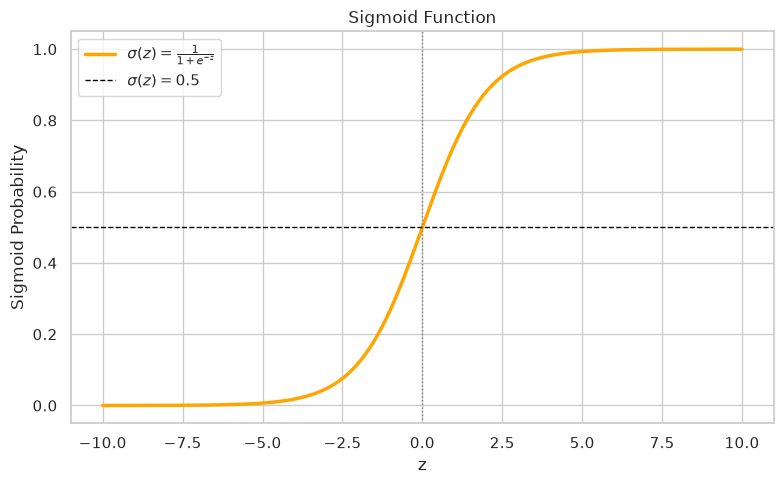

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

z_val = np.linspace(-10, 10, 300) 
sigma_val = sigmoid(z_val)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(z_val, sigma_val, color="orange", lw=2.5, label="$\\sigma(z) = \\frac{1}{1 + e^{-z}}$")
ax.axhline(0.5, color="black", ls="--", lw=1, label="$\\sigma(z)=0.5$")
ax.axvline(0.0, color="gray", ls=":", lw=1)
ax.set_title("Sigmoid Function")
ax.set_xlabel("z")
ax.set_ylabel("Sigmoid Probability")
ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

TASK 03  
Method 1 — Logistic Regression from scratch

In [5]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.1, n_iters=1500):
        self.lr = lr
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, x, y):
        m, n = x.shape
        self.w = np.zeros(n)
        self.b = 0.0
        self.loss_history = []

        for i in range(self.n_iters):
            # Forward pass: linear combination + sigmoid
            z = x @ self.w + self.b
            p = sigmoid(z)

            # Compute cross-entropy loss (with epsilon clipping to avoid log(0))
            p_clip = np.clip(p, 1e-15, 1 - 1e-15)
            loss = - (1/m) * np.sum(y * np.log(p_clip) + (1 - y) * np.log(1 - p_clip))
            self.loss_history.append(loss)

            # Gradient computation
            dz = p - y
            dw = (1/m) * (x.T @ dz)
            db = (1/m) * np.sum(dz)

            # Parameter updates
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict_proba(self, x):
        z = x @ self.w + self.b
        return sigmoid(z)

    def predict(self, x, threshold=0.5):
        return (self.predict_proba(x) >= threshold).astype(int)

# Train from scratch
scratch_model = LogisticRegressionScratch(lr=0.15, n_iters=2000)
scratch_model.fit(x_train_scaled, y_train)

print("From-Scratch Training Complete!")
print(f"Learned Intercept (bias b): {scratch_model.b:.4f}")
print("Learned Weights (w):")
for feat, weight in zip(x.columns, scratch_model.w):
    print(f"  {feat:10s}: {weight:.4f}")

From-Scratch Training Complete!
Learned Intercept (bias b): -0.2780
Learned Weights (w):
  Pclass    : -0.6965
  Sex       : 1.1661
  Age       : -0.0610
  SibSp     : -0.2123
  Parch     : -0.0432
  Fare      : 0.1217


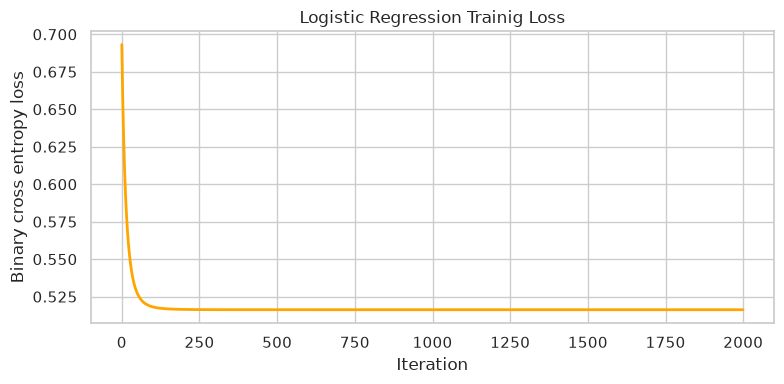

In [6]:
# Plot training loss
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(scratch_model.loss_history, color="orange", lw=2)
ax.set_title("Logistic Regression Trainig Loss")
ax.set_xlabel("Iteration")
ax.set_ylabel("Binary cross entropy loss")
plt.tight_layout()
plt.show()

TASK 04  
Method 2 — Scikit-Learn parity proof

In [7]:
from sklearn.linear_model import LogisticRegression

# Fit sklearn Logistic Regression
sk_model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
sk_model.fit(x_train_scaled, y_train)

# Display Scratch vs Sklearn weights
parity_df = pd.DataFrame({
    'Feature': ['Intercept (bias)'] + list(x.columns),
    'From-Scratch (NumPy)': [scratch_model.b] + list(scratch_model.w),
    'Scikit-Learn': [sk_model.intercept_[0]] + list(sk_model.coef_[0]),
})
parity_df['Abs Difference'] = np.abs(parity_df['From-Scratch (NumPy)'] - parity_df['Scikit-Learn'])

print("Parameter Parity Comparison:")
print(parity_df.to_string(index=False))

Parameter Parity Comparison:
         Feature  From-Scratch (NumPy)  Scikit-Learn  Abs Difference
Intercept (bias)             -0.278050     -0.278052        0.000002
          Pclass             -0.696506     -0.696723        0.000217
             Sex              1.166072      1.166253        0.000180
             Age             -0.060972     -0.061025        0.000054
           SibSp             -0.212330     -0.212460        0.000129
           Parch             -0.043226     -0.043259        0.000033
            Fare              0.121742      0.121748        0.000007


/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [8]:
# Check whether weights match within 1e-3
max_weight_diff = np.max(
    np.abs(parity_df['Abs Difference'])
)

print("Maximum absolute weight difference:", max_weight_diff)
print("Weights match within 1e-3:", max_weight_diff < 1e-3)

Maximum absolute weight difference: 0.00021711401859103585
Weights match within 1e-3: True


In [9]:
# Compare predictions on test set
pred_scratch = scratch_model.predict(x_test_scaled)
pred_sklearn = sk_model.predict(x_test_scaled)
print(f"\nPredictions Match Rate: {(pred_scratch == pred_sklearn).mean()*100:.1f}%")


Predictions Match Rate: 100.0%


Part C — Measure, Tune, and Interpret  
TASK 05  
Confusion Matrix and Classification Metrics

In [10]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Predictions on test set
cm = confusion_matrix(y_test, pred_sklearn)
acc = accuracy_score(y_test, pred_sklearn)
prec = precision_score(y_test, pred_sklearn)
recall = recall_score(y_test, pred_sklearn)
f1 = f1_score(y_test, pred_sklearn)

tn, tp, fn, fp = confusion_matrix(y_test, pred_sklearn).ravel()

print("Confusion matrix:")
print(f"True Negative(TN): {tn}")
print(f"True Positive(TP): {tp}")
print(f"False Negative(FN): {fn}")
print(f"False Positive (FP): {fp}")

Confusion matrix:
True Negative(TN): 86
True Positive(TP): 26
False Negative(FN): 21
False Positive (FP): 67


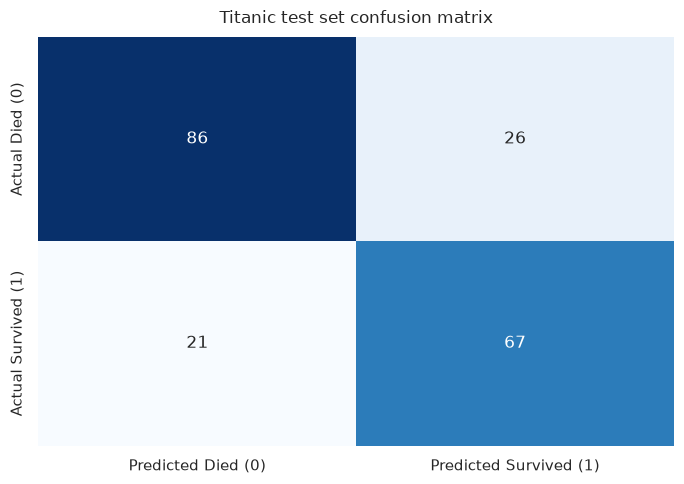

In [11]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
           xticklabels=["Predicted Died (0)", "Predicted Survived (1)"],
           yticklabels=["Actual Died (0)", "Actual Survived (1)"], ax=ax)
ax.set_title("Titanic test set confusion matrix", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

In [12]:
print("Classification Matrics Summary (Test Set):")
print(f"Accuracy : {acc*100:.2f}%")
print(f"Precision : {prec*100:.2f}%")
print(f"Recall : {recall*100:.2f}%")
print(f"f1 Score : {f1*100:.2f}%")

Classification Matrics Summary (Test Set):
Accuracy : 76.50%
Precision : 72.04%
Recall : 76.14%
f1 Score : 74.03%


TASK 06  
Decision Threshold Tuning and the ROC-AUC Curve

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

# Predicted probabilities
test_probs = sk_model.predict_proba(x_test_scaled)[:,1]

# Threshold sweep: 0.2, 0.5, 0.8
thresholds = [0.2, 0.5, 0.8]

for threshold in thresholds:
    y_pred = (test_probs >= threshold).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print(f"\nThreshold : {threshold}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")


Threshold : 0.2
Precision : 0.618
Recall    : 0.920

Threshold : 0.5
Precision : 0.720
Recall    : 0.761

Threshold : 0.8
Precision : 1.000
Recall    : 0.375


At a lower threshold such as 0.2, the model classifies more observations as positive, which generally increases Recall but can reduce Precision. At the default threshold of 0.5, Precision and Recall provide a middle-ground operating point. At a higher threshold such as 0.8, the model becomes more conservative when predicting the positive class, generally increasing Precision while reducing Recall.

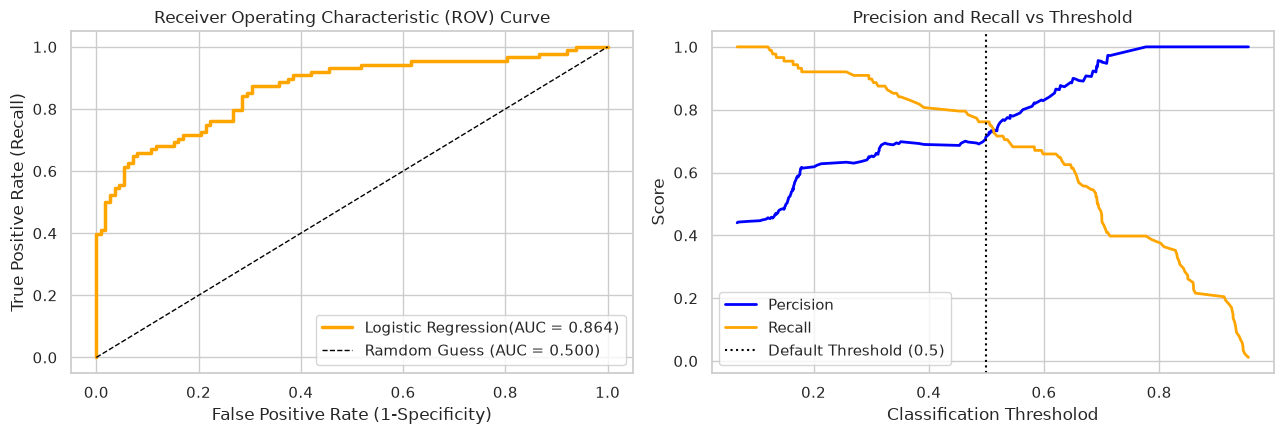

In [18]:
# ROC Curve and ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test, test_probs)
auc_score = roc_auc_score(y_test, test_probs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Roc Curve
ax1.plot(fpr, tpr, color='orange', lw=2.5, label=f"Logistic Regression(AUC = {auc_score:.3f})")
ax1.plot([0, 1], [0, 1], color="black", ls='--', lw=1, label='Ramdom Guess (AUC = 0.500)')
ax1.set_title("Receiver Operating Characteristic (ROV) Curve", fontsize=12)
ax1.set_xlabel("False Positive Rate (1-Specificity)")
ax1.set_ylabel("True Positive Rate (Recall)")
ax1.legend(loc="lower right")

# Precision and Recall vs Threshold
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, test_probs)
ax2.plot(pr_thresholds, precisions[:-1], color='blue', lw=2, label="Percision")
ax2.plot(pr_thresholds, recalls[:-1], color='orange', lw=2, label="Recall")
ax2.axvline(0.5, color='black', ls=':', label="Default Threshold (0.5)")
ax2.set_title("Precision and Recall vs Threshold", fontsize=12)
ax2.set_xlabel("Classification Thresholod")
ax2.set_ylabel("Score")
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

A high Recall means the system detects a larger proportion of patients who actually have the disease, reducing dangerous false negatives. Precision is still important because too many false positives can cause unnecessary tests and anxiety, so the ideal threshold depends on the medical consequences of false positives versus false negatives.

TASK 07  
Odds Ratios and Plain-English Model Interpretation

In [19]:
coef_df = pd.DataFrame({
    'Feature': x.columns,
    'Weight': sk_model.coef_[0],
    'Odds_Ratio': np.exp(sk_model.coef_[0])
}).sort_values(by='Weight', ascending=True)

print("Features, Weights and Odds Ratios:")
print(coef_df.sort_values(by='Weight', ascending=False).to_string(index=False))

Features, Weights and Odds Ratios:
Feature    Weight  Odds_Ratio
    Sex  1.166253    3.209942
   Fare  0.121748    1.129470
  Parch -0.043259    0.957663
    Age -0.061025    0.940799
  SibSp -0.212460    0.808593
 Pclass -0.696723    0.498215


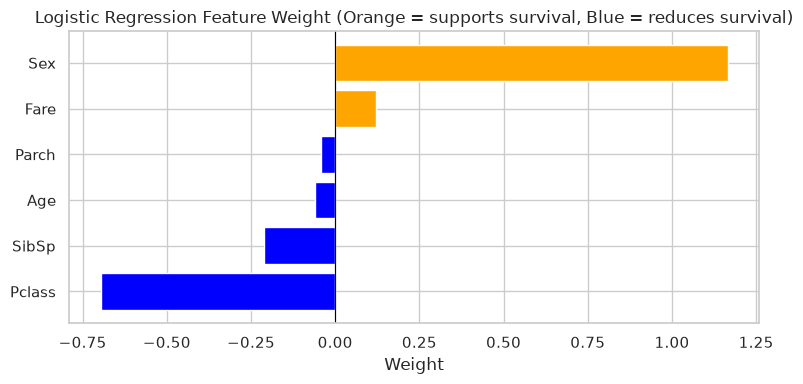

In [21]:
# Horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ['orange' if w > 0 else 'blue' for w in coef_df['Weight']]
ax.barh(coef_df['Feature'], coef_df['Weight'], color=bar_colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title("Logistic Regression Feature Weight (Orange = supports survival, Blue = reduces survival)")
ax.set_xlabel("Weight")
plt.tight_layout()
plt.show()

For the Titanic model, sex is expected to be one of the strongest demographic drivers of survival, with being female associated with substantially higher survival odds than being male. Passenger class also strongly affects survival, with higher-class passengers generally having better survival chances, reflecting differences in access to lifeboats and evacuation conditions. Age has a negative relationship with survival, meaning older passengers tend to have lower predicted survival odds than younger passengers when other features are held constant. Overall, the model shows that demographic and socioeconomic characteristics such as sex, age, and passenger class played an important role in determining survival.